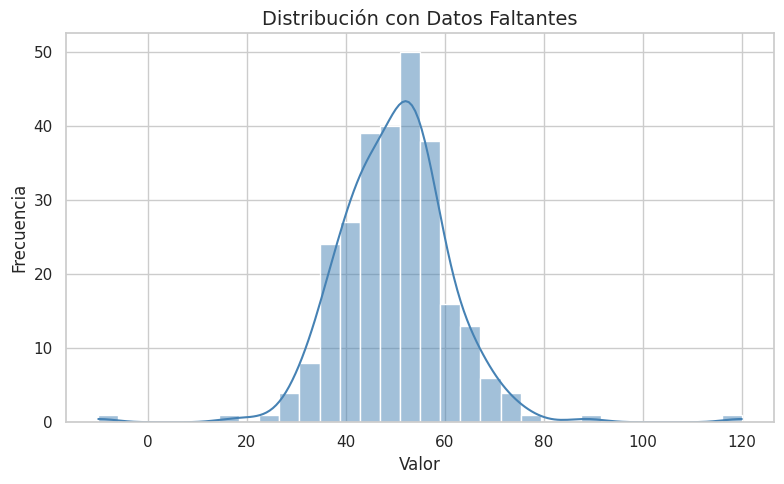

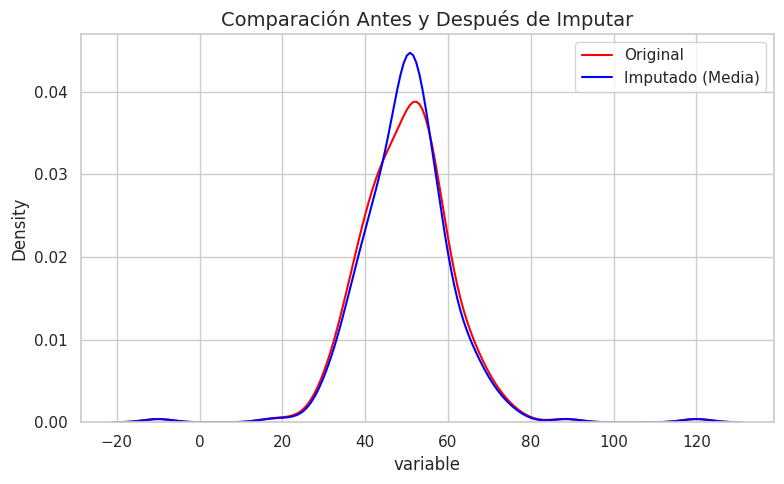

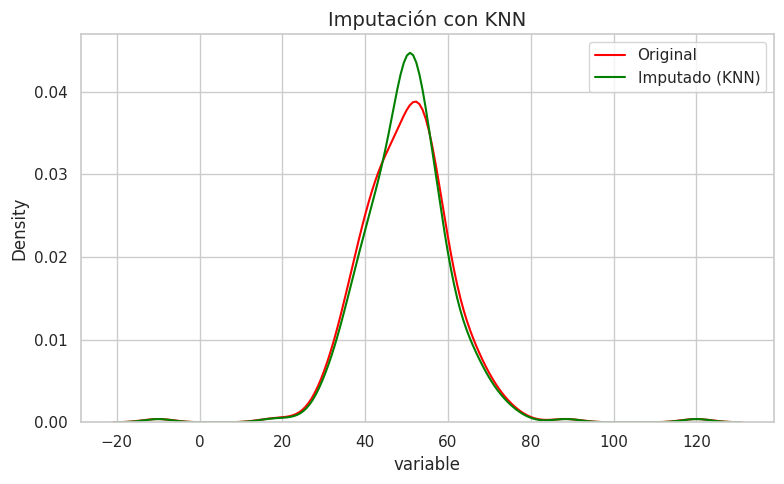

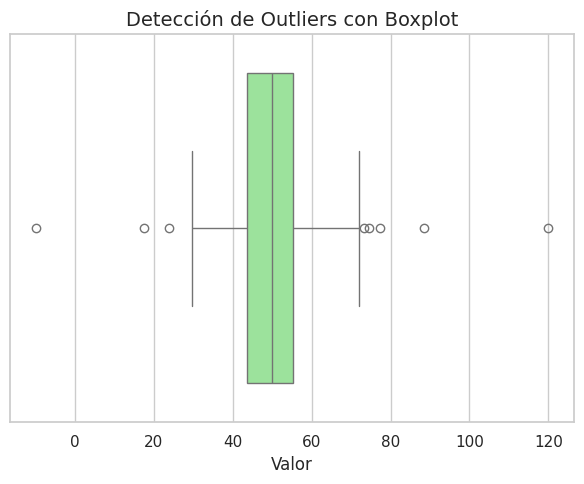

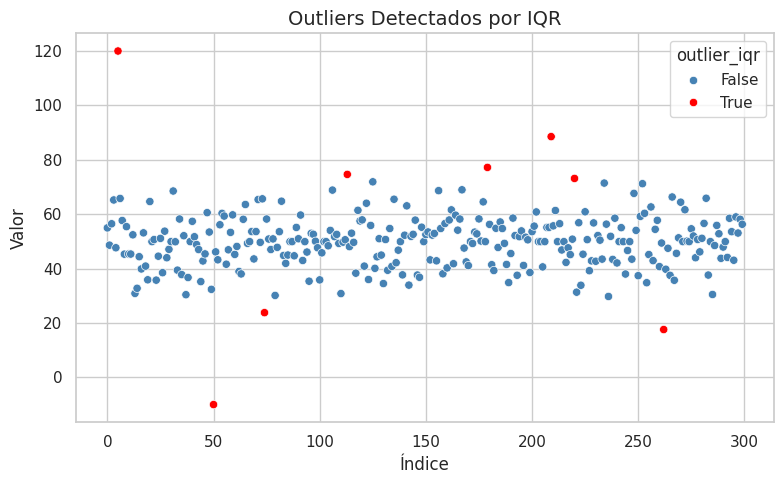

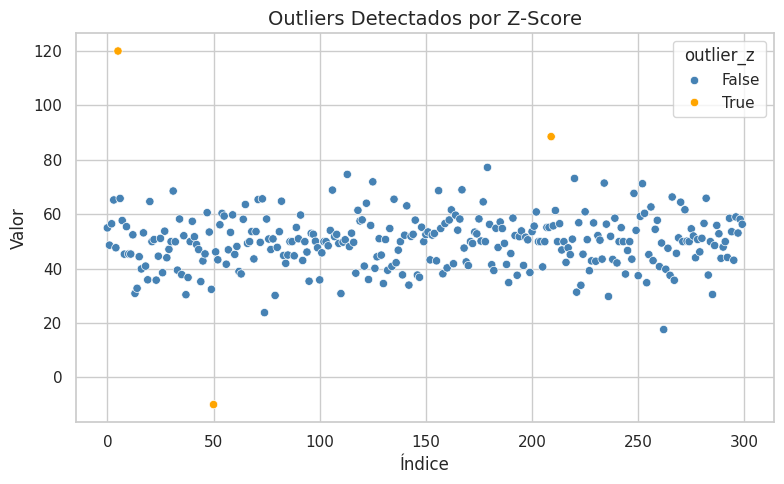

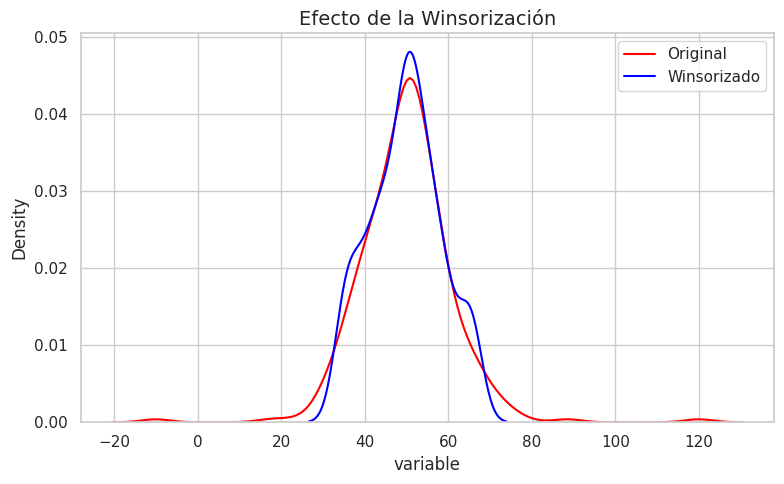

In [3]:
# ============================================
#   LIBRERÍAS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from scipy import stats

from sklearn.preprocessing import PowerTransformer

sns.set(style="whitegrid")

# ============================================
#   GENERACIÓN DE DATOS
# ============================================
np.random.seed(42)
data = np.random.normal(50, 10, 300)

# Introducir outliers
data[5] = 120
data[50] = -10

# Introducir valores faltantes
data[np.random.choice(300, 25, replace=False)] = np.nan

df = pd.DataFrame({"variable": data})

# ============================================
#   1. DISTRIBUCIÓN CON DATOS FALTANTES
# ============================================
plt.figure(figsize=(8,5))
sns.histplot(df["variable"], kde=True, color="steelblue")
plt.title("Distribución con Datos Faltantes", fontsize=14)
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# ============================================
#   2. IMPUTACIÓN POR MEDIA
# ============================================
df_mean = df.copy()
df_mean["variable"] = df_mean["variable"].fillna(df["variable"].mean())

plt.figure(figsize=(8,5))
sns.kdeplot(df["variable"], label="Original", color="red")
sns.kdeplot(df_mean["variable"], label="Imputado (Media)", color="blue")
plt.title("Comparación Antes y Después de Imputar", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
#   3. IMPUTACIÓN KNN
# ============================================
imputer = KNNImputer(n_neighbors=5)
df_knn = df.copy()
df_knn["variable"] = imputer.fit_transform(df_knn[["variable"]])

plt.figure(figsize=(8,5))
sns.kdeplot(df["variable"], label="Original", color="red")
sns.kdeplot(df_knn["variable"], label="Imputado (KNN)", color="green")
plt.title("Imputación con KNN", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================
#   4. BOXPLOT PARA DETECTAR OUTLIERS
# ============================================
plt.figure(figsize=(6,5))
sns.boxplot(x=df_knn["variable"], color="lightgreen")
plt.title("Detección de Outliers con Boxplot", fontsize=14)
plt.xlabel("Valor")
plt.tight_layout()
plt.show()

# ============================================
#   5. OUTLIERS POR IQR
# ============================================
Q1 = df_knn["variable"].quantile(0.25)
Q3 = df_knn["variable"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_knn["outlier_iqr"] = (df_knn["variable"] < lower) | (df_knn["variable"] > upper)

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_knn, x=range(len(df_knn)), y="variable",
                hue="outlier_iqr", palette={False:"steelblue", True:"red"})
plt.title("Outliers Detectados por IQR", fontsize=14)
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

# ============================================
#   6. OUTLIERS POR Z-SCORE
# ============================================
z_scores = np.abs(stats.zscore(df_knn["variable"]))
df_knn["outlier_z"] = z_scores > 3

plt.figure(figsize=(8,5))
sns.scatterplot(x=range(len(df_knn)), y=df_knn["variable"],
                hue=df_knn["outlier_z"], palette={False:"steelblue", True:"orange"})
plt.title("Outliers Detectados por Z-Score", fontsize=14)
plt.xlabel("Índice")
plt.ylabel("Valor")
plt.tight_layout()
plt.show()

# ============================================
#   7. WINSORIZACIÓN
# ============================================
df_win = df_knn.copy()
df_win["winsor"] = stats.mstats.winsorize(df_win["variable"], limits=[0.05, 0.05])

plt.figure(figsize=(8,5))
sns.kdeplot(df_knn["variable"], label="Original", color="red")
sns.kdeplot(df_win["winsor"], label="Winsorizado", color="blue")
plt.title("Efecto de la Winsorización", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()
